In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Clean veri dizini tespiti
if os.path.exists(os.path.join("Data", "Clean")):
  clean_path = os.path.join("Data", "Clean")
elif os.path.exists(os.path.join("..", "Data", "Clean")):
  clean_path = os.path.join("..", "Data", "Clean")
else:
  clean_path = os.path.join("..", "..", "Data", "Clean")

# Master veriyi okuyoruz
df = pd.read_csv(os.path.join(clean_path, "master_orders_clean.csv"))
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

print(f"✔ Veri Yüklendi: {len(df):,} Satır\n")

# 1. RFM METRİKLERİNİN HESAPLANMASI
analysis_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("customer_unique_id")
    .agg({
        "order_purchase_timestamp": lambda x: (analysis_date - x.max()).days,
        "order_id": "nunique",
        "total_price": "sum",
    })
    .reset_index()
)

rfm.columns = ["customer_id", "recency", "frequency", "monetary"]

# 2. K-MEANS MAKİNE ÖĞRENMESİ İLE KÜMELEME
X = rfm[["recency", "frequency", "monetary"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

# Küme isimlerini atayalım
cluster_names = {
    0: "At Risk (Risk Altındakiler)",
    1: "Loyal Customers (Sadık Müşteriler)",
    2: "New & Promising (Yeni / Potansiyel)",
    3: "Lost Customers (Kaybedilenler)",
}
rfm["segment"] = rfm["cluster"].map(cluster_names)

print(" Müşteri Segmentasyonu Dağılımı ")
print(rfm["segment"].value_counts())

# 3. SONUÇLARI DATA/CLEAN KLASÖRÜNE KAYDETME
rfm.to_csv(os.path.join(clean_path, "rfm_segments.csv"), index=False)
print(
    "\n🎉 İŞLEM TAMAMLANDI! Müşteri segmentleri 'Data/Clean/rfm_segments.csv'"
    " dosyasına kaydedildi."
)

✔ Veri Yüklendi: 112,650 Satır

 Müşteri Segmentasyonu Dağılımı 
segment
At Risk (Risk Altındakiler)            51787
Loyal Customers (Sadık Müşteriler)     38286
New & Promising (Yeni / Potansiyel)     2881
Lost Customers (Kaybedilenler)          2466
Name: count, dtype: int64

🎉 İŞLEM TAMAMLANDI! Müşteri segmentleri 'Data/Clean/rfm_segments.csv' dosyasına kaydedildi.


C:\Users\Betül Bağcı\AppData\Local\Temp\ipykernel_14724\3743940954.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


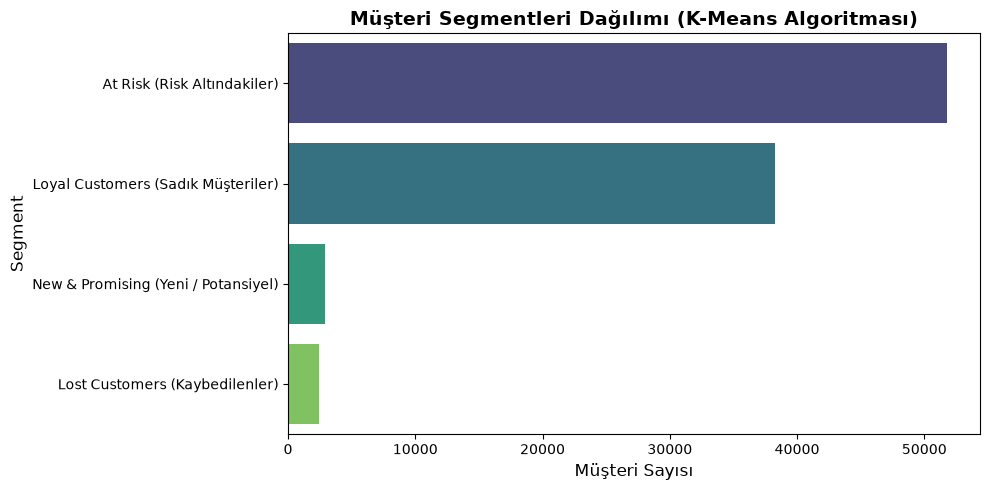

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=rfm,
    y="segment",
    palette="viridis",
    order=rfm["segment"].value_counts().index,
)
plt.title(
    "Müşteri Segmentleri Dağılımı (K-Means Algoritması)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Müşteri Sayısı", fontsize=12)
plt.ylabel("Segment", fontsize=12)
plt.tight_layout()
plt.show()